# Homework 5: LLM Fine-tuning with Transformers

In this homework you will be **finetuning a small instruction-tuned Language Model (LLM) to do well on previous 189 exam problems while maintaining its general knowledge capabilities.** We will be evaluating you on a hidden test set containing 189 exam problems and general knowledge questions, all in multiple choice format.

We will walk you through how to fine-tune on custom datasets using the standard Hugging Face `transformers` and `trl` libraries.

In this notebook, we use **Qwen/Qwen2.5-0.5B-Instruct**. This is a small but capable model (0.5 billion parameters) that fits easily on most GPUs and trains quickly, allowing us to perform **full fine-tuning** (updating all weights) rather than needing parameter-efficient methods like LoRA (although you are welcome to use LoRA instead).

In this notebook, we provide a small subset of CS189 Exam Questions for you to test and a walkthrough of a simple finetuning pipeline. The actual test set you would be making predictions will be a mix of different questions (Full details are provided in the accompanying PDF)

## Overview
Your task is to:
1. **Adapt the provided notebook**
2. **Generate predictions** on the private test questions (test.csv)
3. **Submit** your results to Kaggle  

**Kaggle competition link:**  
https://www.kaggle.com/t/11c8ffdc967fe3f27755cde6fb5810e8

---
### Rules

You are encouraged to improve the model's performance!

**What you CAN change:**
- **Parsing Logic:** You can improve `parse_choice_from_boxed` to handle more edge cases or different output formats.
- **Training and Testing Data:** You can mix in additional datasets to the training set and build your own eval sets to test if your model is overfitting.
- **Test-Time Adaptations:** You can try different decoding strategies, majority voting, or other inference-time techniques.
- **Prompt Engineering:** You can experiment with Chain-of-Thought (CoT) prompting or different system prompts during inference.

**What you CANNOT change:**
- **The Model:** You must train the `Qwen/Qwen2.5-0.5B-Instruct` model. Do not switch to a different model architecture or size.
- **Colab Compatibility:** Your final notebook must be runnable in Google Colab. Do not add dependencies or steps that break this compatibility.

#### Evaluation

**Important:** Your model will be evaluated on a hidden test set containing both:
1.  **CS189 Exam Problems:** Similar to the ones in your training set.
2.  **General Knowledge Questions:** To check if the model has retained its general capabilities.

**Catastrophic Forgetting:**
As shown in the paper you read for this homework, fine-tuning on a narrow dataset (e.g. just CS189 MCQs) can sometimes cause the model to "forget" how to answer general questions or lose its reasoning abilities.

**Recommendation:**
We strongly encourage you to build your own **test set** that includes both domain-specific and general knowledge questions. Use this to monitor your model's performance and ensure it isn't suffering from catastrophic forgetting. You might want to mix in some general datasets during training or use early stopping to prevent this (the paper you read will be useful here).

---
## The Finetuning Pipeline

Now let's walk through a simple finetuning pipeline using the Hugging Face `transformers` and `trl` libraries. Even though we are using a smaller model, the core structure of the finetuning pipeline follows the classic **ML Lifecycle** covered in lecture!

<img src="https://i.imgur.com/ya2hBEk.png" width="60%">

---

## Learning Problem (P)

**Goal:** Decide what behavior we want the LLM to learn, and from what data.

We want to fine-tune our base Qwen model to better perform on CS189-style multiple choice questions. Our objective is to minimize cross-entropy loss on a dataset of these questions.

Concretely, we will:
- **Load the CS189 MCQ dataset:** A CSV file containing questions, options (A-E), and the correct answer.
- **Format the data:** Convert each row into a "chat" format that the model understands.
  - User: The question + options.
  - Assistant: The correct answer (e.g., `\boxed{A}`).

---
## Model Design (L)

**Goal:** Decide which model we use and how we adapt it.

We use **Qwen/Qwen2.5-0.5B-Instruct**.
- **Architecture:** A Transformer-based Causal Language Model.
- **Adaptation:** We use **Full Fine-tuning**. Since the model is small, we can update all parameters. This differs from "LoRA" (Low-Rank Adaptation) which is often used for larger models (7B+) to save memory.

---
## Optimization (M)

**Goal:** Train the model on the dataset by minimizing loss.

We use TRL’s `SFTTrainer` (Supervised Fine-Tuning Trainer) to perform gradient-based optimization:
- **Loss function:** Standard token-level cross-entropy loss.
- **Optimizer:** AdamW (8-bit version to save some memory, though standard AdamW may also fit depending on your GPU).
- **Hyperparameters:** Learning rate, batch size, etc.

---
## Predict & Evaluate (O)

**Goal:** Check whether the fine-tuned model behaves as desired.

After training, we:
- **Run inference:** Ask the model to answer the MCQs.
- **Compute accuracy:** Check if the model's output (parsed from `\boxed{X}`) matches the ground truth.
- **Compare:** We measure accuracy *before* and *after* fine-tuning to quantify improvement.

---
## Part 0: Environment Setup

This cell installs and imports the required libraries.

In [1]:
import sys
IS_COLAB = 'google.colab' in sys.modules
if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/cs189/hw/hw5
    ! pip install -q transformers==4.57.2 accelerate datasets trl bitsandbytes

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/cs189/hw/hw5


In [2]:
!pip install sentence-transformers faiss-cpu
import os
import re
import math
import pandas as pd
import torch
import faiss
from datasets import Dataset, load_dataset, load_from_disk,Value, concatenate_datasets
from trl import SFTTrainer, SFTConfig
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import random

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#MAKE SURE YOU ARE USING GPU
print('Using device:', device)

Using device: cuda


---
## Part 1: Configuration & Model Loading

Here we define all our settings and load the base model.

**Model Design (L):** We select `Qwen/Qwen2.5-0.5B-Instruct`.

In [3]:
5# ============================================================================
# === CONFIGURATION - ALL SETTINGS IN ONE PLACE ===
# ============================================================================

# --- Model Configuration ---
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct" # YOU CANNOT CHANGE THIS

# --- Dataset Configuration ---
#TODO: REPLACE WITH YOUR OWN PATH
MCQ_CSV_PATH = "hw5_sample_eval.csv"  # Path to CS189 MCQ sample eval dataset

# --- Training Configuration (feel free to adjust!) ---
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
WARMUP_STEPS = 5
MAX_STEPS = 50  # or set num_train_epochs instead
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
LR_SCHEDULER_TYPE = "linear"
OPTIM = "adamw_8bit"  # requires bitsandbytes
SEED = 189

# --- Evaluation Configuration ---
EVAL_MAX_NEW_TOKENS = 64  # How many tokens to generate for inference
OUTPUT_DIR = "./mcq_finetuned_model"

In [4]:
# # === Load base model & tokenizer ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# # Ensure we have a pad token for training
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

model.resize_token_embeddings(len(tokenizer))
model.to(device)
model.eval()
print('Model loaded.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
`torch_dtype` is deprecated! Use `dtype` instead!


Model loaded.


---
## Part 2: Data Preparation

**Learning Problem (P):** We need to format our raw CSV data into training examples.

We define helper functions to:
1.  Load the CSV.
2.  Build a "prompt" (Question + Options).
3.  Build the full "SFT text" (Prompt + Answer) using the model's chat template.

In [5]:

# === MCQ helpers ===
LETTER_SET = set(list("ABCDE"))

def load_mcq_dataset(csv_path: str = MCQ_CSV_PATH):
    """Load the CS189 MCQ dataset.

    Expected columns:
        - question
        - A, B, C, D, E
        - answer (single letter A-E)
    """
    df = pd.read_csv(csv_path)
    required = ["question", "A", "B", "C", "D", "E", "answer"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in MCQ CSV: {missing}")

    df = df.copy()
    df["answer"] = (
        df["answer"]
        .astype(str)
        .str.strip()
        .str.upper()
    )
    df = df[df["answer"].isin(LETTER_SET)].reset_index(drop=True)
    return df

def build_mcq_prompt(row):
    """Prompt for inference: instruction + question + options.

    The model is expected to answer with the correct letter in \\boxed{} format.
    """
    q = str(row["question"]).strip()
    options = "\n".join([
        f"A. {row['A']}",
        f"B. {row['B']}",
        f"C. {row['C']}",
        f"D. {row['D']}",
        f"E. {row['E']}",
    ])
    prompt = (
        "Choose exactly one correct option from A, B, C, D, and E.\n"
        "Return your answer inside a LaTeX box.\n\n"
        f"{q}\n\n{options}\n\nAnswer:"
    )
    return prompt


def build_mcq_sft_text(row, tokenizer):
    """
    Format a single MCQ row into the same SFT-style chat text
    as build_mmlu_sft_text.
    """
    user_content = build_mcq_prompt(row)

    # Handle answer either as "A"/"B"/... or as 0/1/2/...
    ans = row["answer"]
    if isinstance(ans, str):
        # e.g. "D"
        answer_letter = ans.strip()
    else:
        # e.g. 0–4 integer
        answer_letter = chr(ord("A") + int(ans))

    assistant_content = f"\\boxed{{{answer_letter}}}"

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content},
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

### Understanding the Chat Format (OpenAI Style)

To fine-tune a chat model, we need to structure our data as a conversation. This is often called the **OpenAI Chat Format** or **Messages Format**.

Instead of a single string of text, each example is a list of dictionaries, where each dictionary represents a message in the conversation:
-   `{"role": "user", "content": "..."}`: The input prompt or question.
-   `{"role": "assistant", "content": "..."}`: The model's desired response.

For our MCQ task, we structure it as:
1.  **User**: "Choose exactly one correct option... [Question] ... [Options]"
2.  **Assistant**: "\\boxed{A}"

We then use `tokenizer.apply_chat_template()` to convert this structured list into the specific string format that the model expects (e.g., adding special tokens like `<|im_start|>user...<|im_end|>`).

In [6]:
def parse_choice_from_boxed(text: str):
    """Parse an MCQ choice A–E from the model output.

    We first look for a literal '\\boxed{X}' pattern. If not found, we
    fallback to the last standalone A-E in the decoded text.
    """
    if text is None:
        return None
    # Direct \\boxed{A} ... \\boxed{E}
    m = re.search(r"\\boxed\{\s*([A-E])\s*\}", text)
    if m:
        return m.group(1)
    # Fallback: last standalone A–E
    letters = re.findall(r"\b([A-E])\b", text.upper())
    if letters:
        return letters[-1]
    return None

### **Load and Format the (Eval) Dataset**

We load the MCQ dataset and apply the formatting function.
These are sample eval sets we provided. The actual test set you would be making predictions will be a mix of different questions (Full details are provided in the accompanying PDF)

In [7]:
# === Load MCQ CSV (Evaluation Data) ===
try:
    mcq_df = load_mcq_dataset(MCQ_CSV_PATH)
    print(f"Loaded MCQ dataset with {len(mcq_df)} rows from {MCQ_CSV_PATH}.")
except Exception as e:
    mcq_df = None
    print("Error loading MCQ CSV — check MCQ_CSV_PATH.")
    raise e
mcq_df

Loaded MCQ dataset with 25 rows from hw5_sample_eval.csv.


,id,question,A,B,C,D,E,answer
0,mcq_1,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above,A
1,mcq_2,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.,C
2,mcq_3,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0.",D
3,mcq_4,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above,A
4,mcq_5,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...,B
5,mcq_6,Which of the following statements are TRUE reg...,"In the Bayesian MAP interpretation, Lasso regr...","In Lasso regression, as the regularization coe...",Lasso regression performs both feature expansi...,There is no unique solution to Ridge regressio...,none of the above,B
6,mcq_7,If the model resulting from Ridge regression i...,Collect new data to increase the training data...,Repeat the current data twice to increase the ...,Increase the ℓ1 regularization penalty in the ...,Add new features to the model.,Add synthetic features from the model.,A
7,mcq_8,Which of the following statements are TRUE abo...,"After a gradient descent update step, the obje...",There is always a unique steepest descent dire...,Gradient descent converges to a globally optim...,"Since ReLU is a convex function, a neural netw...",none of the above,C
8,mcq_9,Which of the following statements are TRUE abo...,The value of cross-entropy loss is always non-...,Cross-entropy loss is only suitable for binary...,For two discrete probability distributions P a...,Minimizing the cross-entropy is equivalent to ...,none of the above,A
9,mcq_10,Which of the following statements are TRUE abo...,"During the k-fold cross validation process, pr...","During the k-fold cross validation process, pr...","During the k-fold cross validation process, we...",At the end of the k-fold cross validation proc...,none of the above,A


In [8]:
def build_mcq_eval_dataset(mcq_df, tokenizer):
    """
    Turn the MCQ pandas DataFrame into a Hugging Face Dataset
    with a single 'text' column formatted like the MMLU SFT data.
    """
    # Convert pandas DataFrame to datasets.Dataset
    ds = Dataset.from_pandas(mcq_df.reset_index(drop=True))

    def _format_example(example):
        return {
            "text": build_mcq_sft_text(example, tokenizer)
        }

    ds = ds.map(
        _format_example,
        remove_columns=ds.column_names,   # keep only 'text'
    )
    return ds

In [9]:
eval_dataset = build_mcq_eval_dataset(mcq_df, tokenizer)
print(eval_dataset[0]["text"])  # sanity check

Map:   0%|          | 0/25 [00:00<?, ? examples/s]

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Choose exactly one correct option from A, B, C, D, and E.
Return your answer inside a LaTeX box.

Peanut wants to train a model to accurately classify different types of animals from images. After training and testing his model, he observes that the model has high training error and high test error. What can we most confidently say about the bias/variance characteristics of Peanut’s model?

A. High bias.
B. Low bias.
C. High variance.
D. Low variance.
E. none of the above

Answer:<|im_end|>
<|im_start|>assistant
\boxed{A}<|im_end|>



### **Load Training Dataset (MMLU)**

We will use the **MMLU (Massive Multitask Language Understanding)** dataset, specifically the `machine_learning` subset, as our training data. This helps the model learn general machine learning concepts which should transfer to the CS189 exam problems.

In [10]:
# === MMLU Helper Functions ===
def load_mmlu_dataset(subset: str = "machine_learning", split: str = "test"):
    """Load a subset of the MMLU dataset from Hugging Face."""
    print(f"Loading MMLU dataset (subset={subset}, split={split})...")
    ds = load_dataset("cais/mmlu", subset, split=split)
    return ds

def build_mmlu_prompt(row):
    """Prompt for inference: instruction + question + options."""
    q = str(row["question"]).strip()
    choices = row["choices"]

    options_list = []
    for i, choice in enumerate(choices):
        letter = chr(ord("A") + i)
        options_list.append(f"{letter}. {choice}")
    options_str = "\n".join(options_list)

    prompt = (
        "Choose exactly one correct option from the choices provided.\n"
        "Return your answer inside a LaTeX box.\n\n"
        f"{q}\n\n{options_str}\n\nAnswer:"
    )
    return prompt

def build_mmlu_sft_text(row, tokenizer):
    """Build properly formatted chat template text for training."""
    user_content = build_mmlu_prompt(row)

    answer_int = row["answer"]
    answer_letter = chr(ord("A") + answer_int)
    assistant_content = f"\\boxed{{{answer_letter}}}"

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content}
    ]

    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False
    )

# === Load MMLU Machine Learning Dataset ===
mmlu_ds = load_mmlu_dataset("machine_learning", split="test")
mmlu_text_ds = mmlu_ds.map(lambda x: {"text": build_mmlu_sft_text(x, tokenizer)})
print("Loaded MMLU ML dataset with", len(mmlu_text_ds), "rows")

# Set the training dataset - you can mix and match datasets here
train_dataset = mmlu_text_ds

Loading MMLU dataset (subset=machine_learning, split=test)...
Loaded MMLU ML dataset with 112 rows


Let's look at an example of the training data to see what the model is actually seeing as input. Note that there are now start and stop tokens `<|im_start|>` and `<|im_end|>` as well as the role `user` and `assistant` indicating who is speaking.

In [11]:
# print out what the first row looks like
print(train_dataset[0]['text'])

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Choose exactly one correct option from the choices provided.
Return your answer inside a LaTeX box.

Statement 1| Linear regression estimator has the smallest variance among all unbiased estimators. Statement 2| The coefficients α assigned to the classifiers assembled by AdaBoost are always non-negative.

A. True, True
B. False, False
C. True, False
D. False, True

Answer:<|im_end|>
<|im_start|>assistant
\boxed{D}<|im_end|>



---
## Part 3: Baseline Evaluation

**Predict & Evaluate (O):** Before we train, let's see how the model performs "zero-shot" or "few-shot" (depending on the prompt) on our CS189 questions.

In [12]:
def eval_mcq_accuracy(
    curr_model,
    curr_tokenizer,
    df,
    max_new_tokens: int = 64,
    return_details: bool = False,
):
    """Evaluate a model on the MCQ dataset using greedy decoding.

    If return_details=True, also return a pandas DataFrame with
    [idx, question, A, B, C, D, E, gold, decoded, parsed, correct].
    """
    curr_model.eval()
    n = len(df)
    correct = 0
    total = 0
    records = []

    for idx in range(n):
        row = df.iloc[idx]
        user_content = build_mcq_prompt(row)

        # Apply chat template for inference
        messages = [{"role": "user", "content": user_content}]
        prompt = curr_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs = curr_tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = curr_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
            )

        gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        decoded = curr_tokenizer.decode(gen_tokens, skip_special_tokens=True)

        pred = parse_choice_from_boxed(decoded)
        is_correct = (pred is not None and pred == row["answer"])
        if is_correct:
            correct += 1
        total += 1

        records.append({
            "idx": idx,
            "question": row["question"],
            "A": row["A"],
            "B": row["B"],
            "C": row["C"],
            "D": row["D"],
            "E": row["E"],
            "gold": row["answer"],
            "prompt": prompt,
            "decoded": decoded,
            "parsed": pred,
            "correct": is_correct,
        })

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{n} questions...")

    acc = correct / max(total, 1)
    print(f"MCQ accuracy: {acc * 100:.2f}% ({correct}/{total})")

    details_df = pd.DataFrame(records)
    if return_details:
        return acc, details_df
    return acc

In [13]:
# === Baseline MCQ accuracy before fine-tuning ===
print("Evaluating baseline model on MCQ dataset...")
baseline_acc, baseline_details = eval_mcq_accuracy(
    model,
    tokenizer,
    mcq_df,
    max_new_tokens=EVAL_MAX_NEW_TOKENS,
    return_details=True,
)
baseline_details.head()

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Evaluating baseline model on MCQ dataset...
Processed 20/25 questions...
MCQ accuracy: 28.00% (7/25)


,idx,question,A,B,C,D,E,gold,prompt,decoded,parsed,correct
0,0,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",To determine what we can most confidently say ...,A,True
1,1,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.,C,"<|im_start|>system\nYou are Qwen, created by A...",To determine the area under the ROC curve (AUC...,A,False
2,2,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0.",D,"<|im_start|>system\nYou are Qwen, created by A...",To determine the precision and recall for a cl...,A,False
3,3,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",To determine which modified version of \(X\) a...,A,True
4,4,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...,B,"<|im_start|>system\nYou are Qwen, created by A...",To determine which statement is true regarding...,A,False


---
## Part 4: Training (Optimization)

**Optimization (M):** We now configure the `SFTTrainer`.

We set:
- `dataset_text_field="text"`: Tells the trainer which column contains the formatted chat.
- `learning_rate`, `batch_size`: Standard hyperparameters.
- `optim="adamw_8bit"`: Efficient optimizer.

In [14]:
# === Set up SFTTrainer ===
sft_config = SFTConfig(
    dataset_text_field="text",
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=1,
    optim=OPTIM,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    seed=SEED,
    report_to="none",

    # === CHECKPOINTING EVERY 10 STEPS ===
    save_strategy="steps",
    save_steps=10,
    save_total_limit=3,

    # === EVALUATION EVERY 10 STEPS ===
    eval_strategy="steps",
    eval_steps=10,

    # === BEST MODEL SELECTION ===
    load_best_model_at_end=True,
    metric_for_best_model="loss",  # TRL uses "loss" instead of "eval_loss"
    greater_is_better=False,
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,
)

trainer

Adding EOS to eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


### Run Training

This will iterate through the dataset and update the model's weights.

In [15]:
# === Fine-tune the model ===
model.train()
trainer.train()
model.eval()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
10,1.110500,1.453810,1.273572,5311.000000,0.702597
20,0.940300,1.439658,1.160809,10458.000000,0.719230
30,0.642800,1.453400,1.136983,15732.000000,0.712892
40,0.640200,1.476195,1.094906,21409.000000,0.711831
50,0.693600,1.480803,1.079951,26778.000000,0.719056


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151665, 896)
    (layers): ModuleList(
      (0-23): 24 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=896, out_features=896, bias=True)
          (k_proj): Linear(in_features=896, out_features=128, bias=True)
          (v_proj): Linear(in_features=896, out_features=128, bias=True)
          (o_proj): Linear(in_features=896, out_features=896, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=896, out_features=4864, bias=False)
          (up_proj): Linear(in_features=896, out_features=4864, bias=False)
          (down_proj): Linear(in_features=4864, out_features=896, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((896,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((896,), eps=1e-06)
    (rotary_emb): Qwen2

---
## Part 5: Post-Training Evaluation

**Predict & Evaluate (O):** Now that the model is trained, we evaluate it again on the same MCQ dataset to see if accuracy improved.

In [16]:
# === Evaluate MCQ accuracy after fine-tuning ===
print("Evaluating fine-tuned model on MCQ dataset...")
ft_acc, ft_details = eval_mcq_accuracy(
    model,
    tokenizer,
    mcq_df,
    max_new_tokens=EVAL_MAX_NEW_TOKENS,
    return_details=True,
)
ft_details.head()
print(f"Baseline acc: {baseline_acc:.4f}, Fine-tuned acc: {ft_acc:.4f}")

Evaluating fine-tuned model on MCQ dataset...
Processed 20/25 questions...
MCQ accuracy: 16.00% (4/25)
Baseline acc: 0.2800, Fine-tuned acc: 0.1600


### Save the Model

We save the fine-tuned model and tokenizer so we can use them later.

In [17]:
# === Save fine-tuned model (optional) ===
os.makedirs(OUTPUT_DIR, exist_ok=True)
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print("Saved fine-tuned model to", OUTPUT_DIR)

Saved fine-tuned model to ./mcq_finetuned_model


---

## 🧩 **YOUR TURN — Final Kaggle Submission**

Now it’s your turn to run the *full* ML lifecycle.

You should now be able to load and inspect the **private test CSV**, which contains **169 questions** with mixed types.  
Use your **fine-tuned LLM** to make predictions on these questions.  
**Beware of formatting**: Kaggle will reject incorrectly formatted submissions!

### Objective

Your task is to:

1. **Use the provided notebook** to fine-tune the base model on your own choice of train data (feel free to adapt the one we provided)
2. **Adapt the same pipeline** to run inference on `test.csv`.
3. For each row in `test.csv`, output **exactly one letter** from the set  
   **{A, B, C, D, E}**.
4. Save these predictions in the **strict submission format** described below and
   upload your CSV to Kaggle:
   - https://www.kaggle.com/t/11c8ffdc967fe3f27755cde6fb5810e8



### **Submission Format (Strict)**

Your submission must be a **CSV** with exactly **two columns** — `id` and `prediction` — and a **single header row**.

A valid submission looks like:

| id          | prediction |
|-------------|------------|
| test_00001  | A          |
| test_00002  | A          |
| test_00003  | C          |
| test_00004  | E          |
| ...         | ...        |




### Evaluation Metric

Submissions are evaluated using **accuracy**: the fraction of test examples for which your
predicted answer matches the hidden correct answer.


### Example

| **id**        | **True Answer** | **Your Prediction** | **Correct?** |
|---------------|-----------------|---------------------|--------------|
| `test_00001`  | A               | A                   | Yes          |
| `test_00002`  | A               | B                   | No           |
| `test_00003`  | A               | A                   | Yes          |

Here, the accuracy would be 2/3, or approximately 66.7%

The leaderboard is split into:

- **Public leaderboard**: 50% of the test data  
- **Private leaderboard**: remaining 50% (used for final ranking and grading)


In [29]:
# === Load base model & tokenizer ===
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Ensure we have a pad token for training
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

model.resize_token_embeddings(len(tokenizer))
model.to(device)
model.eval()
print('Model loaded.')

Model loaded.


In [42]:
def load_mmlu_dataset_five_options(subset: str = "machine_learning", split: str = "test"):
    print(f"Loading MMLU dataset (subset={subset}, split={split})...")
    ds = load_dataset("cais/mmlu", subset, split=split)
    ds = ds.cast_column("answer", Value("int64"))
    return ds

def add_option_E(ds, p_flip: float = 0.2, seed: int = SEED):
    rng = random.Random(seed)

    def _map(example):
        choices = list(example["choices"])
        answer = int(example["answer"])
        if len(choices) == 4:
            choices.append("None of the answers.")

        # With probability p_flip, flip correct answer to E
        if rng.random() < p_flip:
            true_answer_text = choices[answer]
            choices[answer] = "None of the answers."
            choices[4] = true_answer_text
            answer = 4

        return {
            "choices": choices,
            "answer": answer,
        }

    return ds.map(_map)

def prepare_mmlu_dataset(subset: str = "machine_learning", split: str = "test",sample_size = None):
  ds = load_mmlu_dataset_five_options(subset, split)
  if sample_size is not None:
    ds = ds.shuffle(seed=SEED).select(range(sample_size))
  ds = add_option_E(ds, p_flip=0.2, seed=SEED)
  ds = ds.map(lambda x: {"text": build_mmlu_sft_text(x, tokenizer)})
  ds = ds.shuffle(seed=SEED)
  return ds

def prepare_mmlu_dataset_rag(subset: str = "machine_learning", split: str = "test",sample_size = None):
  ds = load_mmlu_dataset_five_options(subset, split)
  if sample_size is not None:
    ds = ds.shuffle(seed=SEED).select(range(sample_size))
  ds = add_option_E(ds, p_flip=0.2, seed=SEED)
  ds = ds.map(lambda x: {"text": build_mmlu_sft_text_rag(x, tokenizer)})
  ds = ds.shuffle(seed=SEED)
  return ds

In [31]:
mmlu_ds = prepare_mmlu_dataset()
specialised_dataset = mmlu_ds

Loading MMLU dataset (subset=machine_learning, split=test)...


In [32]:
# ============================================================================
# === CONFIGURATION - ALL SETTINGS IN ONE PLACE ===
# ============================================================================

# --- Model Configuration ---
MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct" # YOU CANNOT CHANGE THIS

# --- Dataset Configuration ---
#TODO: REPLACE WITH YOUR OWN PATH
MCQ_CSV_PATH = "hw5_sample_eval.csv"  # Path to CS189 MCQ sample eval dataset

# --- Training Configuration (feel free to adjust!) ---
TRAIN_BATCH_SIZE = 1 # how many examples the device sees at one time
GRADIENT_ACCUMULATION_STEPS = 4 # over how many examples is loss accumulated before 1 optimiser update(step) is performed
WARMUP_STEPS = 5 # how many optimiser updates are ignored at the start (noisy/unstable gradients)
MAX_STEPS = 50  # how many times will optimiser be updated (epochs will be of less priority)
LEARNING_RATE = 1e-5
WEIGHT_DECAY = 0.01
LR_SCHEDULER_TYPE = "cosine" # after warm-up steps, how will LR decay to 0 over remaining steps
OPTIM = "adamw_8bit"  # requires bitsandbytes
SEED = 189

# --- Evaluation Configuration ---
EVAL_MAX_NEW_TOKENS = 64  # How many tokens to generate for inference
OUTPUT_DIR = "./mcq_finetuned_model"

Adding EOS to train dataset:   0%|          | 0/112 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/112 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/112 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

Truncating eval dataset:   0%|          | 0/25 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
5,3.091800,2.103159,2.055308,2781.000000,0.603155
10,1.558000,1.444420,1.271892,5272.000000,0.697957
15,0.905200,1.406067,1.132924,7885.000000,0.718818
20,0.910700,1.381190,1.114754,10725.000000,0.721369
25,0.817100,1.400423,1.064336,13683.000000,0.721138
30,0.826100,1.395964,1.062810,16572.000000,0.720887
35,0.713000,1.392391,1.055517,19498.000000,0.721917
40,0.664700,1.396590,1.047643,22061.000000,0.720471
45,0.675200,1.396983,1.045261,24904.000000,0.717792
50,0.666600,1.397565,1.043698,27828.000000,0.724437


There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


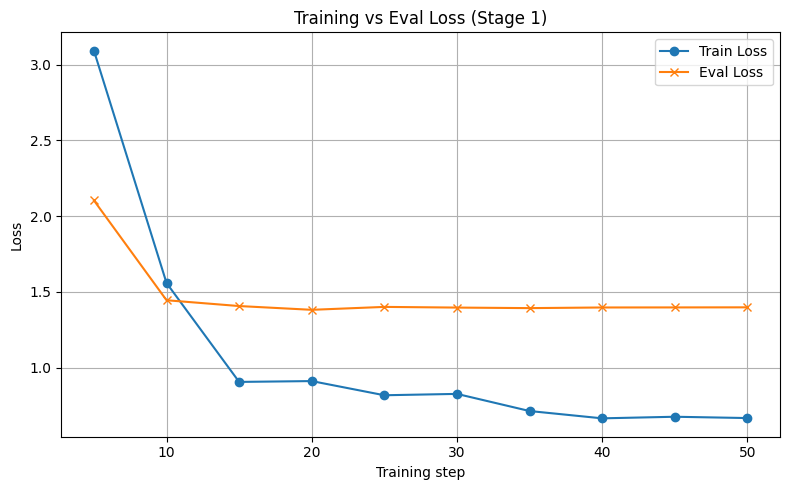

In [33]:
sft_stage1_config = SFTConfig(
    dataset_text_field="text",
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    warmup_steps=WARMUP_STEPS,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    logging_steps=5,
    optim=OPTIM,
    weight_decay=WEIGHT_DECAY,
    lr_scheduler_type=LR_SCHEDULER_TYPE,
    seed=SEED,
    report_to="none",

    # === CHECKPOINTING EVERY 10 STEPS ===
    save_strategy="steps",
    save_steps=10,
    save_total_limit=3,

    # === EVALUATION EVERY 10 STEPS ===
    eval_strategy="steps",
    eval_steps=5,

    # === BEST MODEL SELECTION ===
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
)
trainer_1 = SFTTrainer(
    model=model,
    train_dataset=specialised_dataset,
    eval_dataset=eval_dataset,
    args=sft_stage1_config,
    processing_class=tokenizer,
)


train_result = trainer_1.train()
trainer_1.save_model("qwen_dmt_stage1_mmlu")
tokenizer.save_pretrained("qwen_dmt_stage1_mmlu")

# === Plot training loss vs steps ===
log_history = trainer_1.state.log_history

steps = [entry["step"] for entry in log_history if "loss" in entry]
losses = [entry["loss"] for entry in log_history if "loss" in entry]
eval_losses = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

plt.figure(figsize=(8,5))
plt.plot(steps, losses, label="Train Loss", marker="o")
plt.plot(steps, eval_losses, label="Eval Loss", marker="x")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training vs Eval Loss (Stage 1)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [34]:
print("Evaluating fine-tuned model on MCQ dataset...")
finetuned_acc, finetuned_details = eval_mcq_accuracy(
    model,
    tokenizer,
    mcq_df,
    max_new_tokens=EVAL_MAX_NEW_TOKENS,
    return_details = True
)
finetuned_details.head()

Evaluating fine-tuned model on MCQ dataset...
Processed 20/25 questions...
MCQ accuracy: 40.00% (10/25)


,idx,question,A,B,C,D,E,gold,prompt,decoded,parsed,correct
0,0,Peanut wants to train a model to accurately cl...,High bias.,Low bias.,High variance.,Low variance.,none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",\boxed{C},C,False
1,1,Consider a binary classification data set with...,Close to zero.,Close to 0.1.,Close to 0.5.,Close to 0.9.,Close to one.,C,"<|im_start|>system\nYou are Qwen, created by A...",\boxed{E},E,False
2,2,"Again, consider a binary classification data s...","The precision is 0.1, and the recall is 0.9.","The precision is 0.9, and the recall is 0.1.","The precision is 1.0, and the recall is 0.9.","The precision is 0.9, and the recall is 1.0.","The precision is 0.1, and the recall is 1.0.",D,"<|im_start|>system\nYou are Qwen, created by A...",\boxed{B},B,False
3,3,Assume we are given X ∈ Rn×d and y ∈ Rn for n ...,"y′ = [ y; 0d ], X′ = [ X; √λ Id ]","y′ = [ y; 1d ], X′ = [ X; √λ Id ]","y′ = [ y; 0d ], X′ = [ X; λ Id ]","y′ = [ y; 1d ], X′ = [ X; λ Id ]",none of the above,A,"<|im_start|>system\nYou are Qwen, created by A...",\boxed{B},B,False
4,4,Which of the following statements are TRUE reg...,“Every entry of a matrix is non-negative” is a...,The singular values of a positive semi-definit...,"If a matrix A is positive semi-definite, then ...",The covariance matrix of any distribution is p...,If the Jacobian of a function is positive semi...,B,"<|im_start|>system\nYou are Qwen, created by A...",\boxed{B},B,True


In [43]:
# ===== RAG HELPER FUNCTIONS ======
def build_rag_corpus_from_mmlu(ds):
    """
    Turn each MMLU example into a text chunk that includes:
    - the question
    - all choices
    - the correct answer in plain text
    """
    def _format(example):
        question = example["question"]
        choices = example["choices"]
        answer_idx = int(example["answer"])
        correct_choice_letter = chr(ord("A") + answer_idx)
        correct_choice_text = choices[answer_idx]

        choices_block = "\n".join(
            f"{chr(ord('A') + i)}. {c}" for i, c in enumerate(choices)
        )

        text = (
            f"Question: {question}\n"
            f"Choices:\n{choices_block}\n\n"
            f"Correct answer: {correct_choice_letter}. {correct_choice_text}\n"
        )

        return {"corpus_text": text}

    rag_corpus = ds.map(_format)
    return rag_corpus


def build_rag_query_from_row(row) -> str:
    """Use question + options as retrieval query."""
    q = str(row["question"]).strip()
    choices_str = " ".join([
        f"A. {row['A']}",
        f"B. {row['B']}",
        f"C. {row['C']}",
        f"D. {row['D']}",
        f"E. {row['E']}",
    ])
    return f"{q} {choices_str}"


def retrieve_contexts_for_row(row, top_k: int = 2):
    """Retrieve top-k corpus_text chunks for this MCQ row."""
    query = build_rag_query_from_row(row)

    q_emb = embed_model.encode(
        [query],
        convert_to_numpy=True,
        normalize_embeddings=True,
    )[0]

    scores, retrieved = rag_corpus.get_nearest_examples(
        "embedding",
        q_emb,
        k=top_k,
    )
    contexts = retrieved["corpus_text"]  # list[str]
    return contexts, scores

def build_rag_user_content(row, contexts):
    base = build_mcq_prompt(row)

    context_block = ""
    for i, ctx in enumerate(contexts, 1):
        context_block += f"[CONTEXT {i}]\n{ctx}\n\n"

    user_content = (
        "Use the following context if it is relevant to the question.\n"
        f"{context_block}"
        f"{base}"
    )
    return user_content

def mmlu_example_to_row(example):
    """Adapt an MMLU example to the 'row' format expected by your RAG helpers."""
    choices = example["choices"]
    row = {
        "question": example["question"],
        "A": choices[0],
        "B": choices[1],
        "C": choices[2],
        "D": choices[3],
        "E": choices[4],
        "answer": example["answer"],
    }
    return row

def build_mmlu_sft_text_rag(example, tokenizer, top_k: int = 2, p_no_context: float = 0.1):
    """
    RAG-aware version of build_mmlu_sft_text.

    Uses your existing:
      - mmlu_example_to_row
      - retrieve_contexts_for_row
      - build_rag_user_content
    """
    import random

    row = mmlu_example_to_row(example)

    if random.random() < p_no_context:
        contexts = []
    else:
        contexts, _ = retrieve_contexts_for_row(row, top_k=top_k)

    user_content = build_rag_user_content(row, contexts)

    ans = example["answer"]
    if isinstance(ans, str):
        answer_letter = ans.strip().upper()
    else:
        answer_letter = chr(ord("A") + int(ans))

    assistant_content = f"\\boxed{{{answer_letter}}}"

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": assistant_content},
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=False,
    )

    return text

In [36]:
rag_corpus = None
corpus_subset = load_mmlu_dataset_five_options(subset="all",split="test")
corpus_subset = add_option_E(corpus_subset,p_flip=0.2,seed=SEED)
rag_corpus = build_rag_corpus_from_mmlu(corpus_subset)

Loading MMLU dataset (subset=all, split=test)...


In [39]:
from sentence_transformers import SentenceTransformer

embed_model_name = "BAAI/bge-small-en-v1.5"
embed_model = SentenceTransformer(embed_model_name)

def embed_batch(batch):
    # batch["corpus_text"] is a list of strings
    embeddings = embed_model.encode(
        batch["corpus_text"],
        batch_size=64,
        convert_to_numpy=True,
        show_progress_bar=False,
        normalize_embeddings=True,
    )
    batch["embedding"] = embeddings.tolist()
    return batch

# Add embedding column
rag_corpus = rag_corpus.map(
    embed_batch,
    batched=True,
    batch_size=64
)

# Tell Datasets that "embedding" is a FAISS indexable column
rag_corpus = rag_corpus.add_faiss_index(column="embedding")

Map:   0%|          | 0/14042 [00:00<?, ? examples/s]

  0%|          | 0/15 [00:00<?, ?it/s]

In [44]:
def predict_mcq_test_with_rag(
    curr_model,
    curr_tokenizer,
    df,
    max_new_tokens: int = 64,
    return_details: bool = False,
    top_k: int = 2,
):
    """
    Use the model + RAG to make predictions on an MCQ test dataframe.
    """
    curr_model.eval()
    n = len(df)
    records = []

    for idx in range(n):
        row = df.iloc[idx]

        contexts, _ = retrieve_contexts_for_row(row, top_k=top_k)
        user_content = build_rag_user_content(row, contexts)

        messages = [{"role": "user", "content": user_content}]
        prompt = curr_tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
        )

        inputs = curr_tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            outputs = curr_model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                pad_token_id=curr_tokenizer.eos_token_id,
            )

        gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
        decoded = curr_tokenizer.decode(gen_tokens, skip_special_tokens=True)

        pred = parse_choice_from_boxed(decoded)
        if pred is None:
            pred = "A"

        records.append({
            "id": row["id"],
            "question": row["question"],
            "A": row["A"],
            "B": row["B"],
            "C": row["C"],
            "D": row["D"],
            "E": row["E"],
            "prompt": prompt,
            "decoded": decoded,
            "parsed": pred,
        })

        if (idx + 1) % 20 == 0:
            print(f"Processed {idx + 1}/{n} questions...")

    details_df = pd.DataFrame(records)

    submission_df = details_df[["id", "parsed"]].rename(
        columns={"parsed": "prediction"}
    )

    if return_details:
        return submission_df, details_df
    return submission_df


In [27]:
# def predict_mcq_test(
#     curr_model,
#     curr_tokenizer,
#     df,
#     max_new_tokens: int = 64,
#     return_details: bool = False,
# ):
#     """
#     Use the model to make predictions on an MCQ test dataframe

#     Returns:
#         submission_df: DataFrame with columns ['id', 'prediction']
#                        (letter A–E), ready for Kaggle.
#         details_df (optional): if return_details=True, a DataFrame with
#                                extra columns for inspection.
#     """
#     curr_model.eval()
#     n = len(df)
#     records = []

#     for idx in range(n):
#         row = df.iloc[idx]
#         user_content = build_mcq_prompt(row)

#         # Apply chat template for inference
#         messages = [{"role": "user", "content": user_content}]
#         prompt = curr_tokenizer.apply_chat_template(
#             messages,
#             tokenize=False,
#             add_generation_prompt=True,
#         )

#         inputs = curr_tokenizer(prompt, return_tensors="pt").to(device)

#         with torch.no_grad():
#             outputs = curr_model.generate(
#                 **inputs,
#                 max_new_tokens=max_new_tokens,
#                 do_sample=False,
#             )

#         gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
#         decoded = curr_tokenizer.decode(gen_tokens, skip_special_tokens=True)

#         pred = parse_choice_from_boxed(decoded)

#         if pred is None:
#             pred = "A"

#         records.append({
#             "id": row["id"],
#             "question": row["question"],
#             "A": row["A"],
#             "B": row["B"],
#             "C": row["C"],
#             "D": row["D"],
#             "E": row["E"],
#             "prompt": prompt,
#             "decoded": decoded,
#             "parsed": pred,
#         })

#         if (idx + 1) % 20 == 0:
#             print(f"Processed {idx + 1}/{n} questions...")

#     details_df = pd.DataFrame(records)

#     submission_df = details_df[["id", "parsed"]].rename(
#         columns={"parsed": "prediction"}
#     )

#     if return_details:
#         return submission_df, details_df
#     return submission_df

In [41]:
YOUR_PATH_TO_TEST_CSV = 'kaggle_test.csv' #TODO: REPLACE WITH YOUR OWN PATH
test_questions = pd.read_csv(YOUR_PATH_TO_TEST_CSV)
test_questions
#TODO:
# 1. Make predictions on your finetuned model
submission_df, debug_df = predict_mcq_test_with_rag(
    curr_model=model,
    curr_tokenizer=tokenizer,
    df=test_questions,
    max_new_tokens=64,
    return_details=True,
)
# 2. submit to kaggle following the expected format (id, prediction)
# Save to CSV
submission_df.to_csv("submission.csv", index=False)

print("Saved submission.csv")
submission_df.head()

Processed 20/169 questions...
Processed 40/169 questions...
Processed 60/169 questions...
Processed 80/169 questions...
Processed 100/169 questions...
Processed 120/169 questions...
Processed 140/169 questions...
Processed 160/169 questions...
Saved submission.csv


,id,prediction
0,test_00000,C
1,test_00001,E
2,test_00002,A
3,test_00003,B
4,test_00004,B


In [54]:
# CATASTROPHIC FORGETTING
# === Load base model & tokenizer ===
baseline_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Ensure we have a pad token for training
if baseline_tokenizer.pad_token is None:
    baseline_tokenizer.pad_token = baseline_tokenizer.eos_token

baseline_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto" if torch.cuda.is_available() else None,
)

baseline_model.resize_token_embeddings(len(baseline_tokenizer))
baseline_model.to(device)
baseline_model.eval()
print('Baseline Model loaded.')

def run_chat(model, tokenizer, user_content, max_new_tokens=128):
    message = [{"role": "user", "content": user_content}]
    prompt = tokenizer.apply_chat_template(
        message,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )

    gen_tokens = outputs[0][inputs["input_ids"].shape[1]:]
    decoded = tokenizer.decode(gen_tokens, skip_special_tokens=True)
    return decoded.strip()

examples = [
    # Q3: catastrophic forgetting
    {
        "id": "Q3_1",
        "type": "catastrophic_forgetting",
        "input": "If it rains, I bring an umbrella out. So if I do not bring an umbrella out, it must mean it is not raining. Is this true?",
    },
    {
        "id": "Q3_2",
        "type": "catastrophic_forgetting",
        "input": "What is the powerhouse of a cell?",
    },

    # Q4: unintended skills
    {
        "id": "Q4_1",
        "type": "unintended_skill",
        "input": "What is 2 + 2? Pick an answer from the following options:\n A.1 \n B.2 \n C.3 \n D.4 \n E.5 "
    },
    {
        "id": "Q4_2",
        "type": "unintended_skill",
        "input": "Explain what Parallelism means mathematically, you have a 30 word limit."
    },
]

results = []

for ex in examples:
    user_prompt = ex["input"]

    base_out = run_chat(baseline_model, baseline_tokenizer, user_prompt)
    tuned_out = run_chat(model, tokenizer, user_prompt)

    results.append({
        "id": ex["id"],
        "type": ex["type"],
        "input": user_prompt,
        "base_output": base_out,
        "tuned_output": tuned_out,
    })

for r in results:
    print("=" * 80)
    print(f"Example {r['id']} ({r['type']})")
    print("- Input:")
    print(r["input"])
    print("\n- Base model output:\n", r["base_output"])
    print("\n- Finetuned/RAG model output:\n", r["tuned_output"])
    print()


Baseline Model loaded.
Example Q3_1 (catastrophic_forgetting)
- Input:
If it rains, I bring an umbrella out. So if I do not bring an umbrella out, it must mean it is not raining. Is this true?

- Base model output:
 Your statement that "if it rains, I bring an umbrella out" and "if I do not bring an umbrella out, it must mean it is not raining" can be analyzed in terms of logical reasoning.

Let's break down the statements:

1. **Statement 1:** If it rains, then I bring an umbrella out.
2. **Statement 2:** If I do not bring an umbrella out, then it is not raining.

To determine whether these statements are logically equivalent or contradictory, we need to consider their implications.

### Analysis:
- **Statement 1** states: "If it rains, then I bring an umbrella

- Finetuned/RAG model output:
 Yes, your statement is correct. If you do not bring an umbrella out when it is raining, then it must be raining because rain is the only thing that would cause someone to need an umbrella.

Examp